# Predicting Electric Vehicle Purchase - Exploratory Data Analysis

**Dataset:** Kaggle Playground S6E9 — Predicting Electric Vehicle Purchase

[Competition Dataset](https://www.kaggle.com/competitions/playground-series-s6e9/data)

[Original Dataset](https://www.kaggle.com/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety)

## 1. Business Problem
The goal of this project is to predict whether a customer will purchase an EV based on demographic data, commute distance, charging infrastructure, and psychological factors. This notebook covers the Exploratory Data Analysis (EDA) and initial feature engineering strategy.**

---
## Setup & First Contact With Your Data

In [ ]:
# === SETUP ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Beautiful plot settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.dpi': 100,
})

print('Setup complete!')

Setup complete!


In [2]:
# === LOAD ALL DATA ===
train = pd.read_csv('dataset/train.csv')
test = pd.read_csv('dataset/test.csv')
original = pd.read_csv('dataset/EV_Adoption_and_Range_Anxiety_Dataset.csv')

print(f'Train shape:    {train.shape[0]:>10,} rows x {train.shape[1]} columns')
print(f'Test shape:     {test.shape[0]:>10,} rows x {test.shape[1]} columns')
print(f'Original shape: {original.shape[0]:>10,} rows x {original.shape[1]} columns')

Train shape:       668,665 rows x 15 columns
Test shape:        286,571 rows x 14 columns
Original shape:     10,000 rows x 15 columns


### Initial Data Observations
1. **668K Rows**: Large dataset allows for stable, complex modeling.
2. **Original Dataset**: 10K rows of real-world data available for augmentation.
3. **Target Variable**: `Will_Buy_EV` is the objective to predict.

In [ ]:
# === FIRST LOOK: Column names and types ===

print('=== ALL COLUMNS ===')
for i, (col, dtype) in enumerate(train.dtypes.items()):
    category = 'NUMERIC' if dtype in ['int64', 'float64'] else 'CATEGORICAL'
    print(f'  {i+1:2d}. {col:35s} {str(dtype):10s} -> {category}')

=== ALL COLUMNS ===
   1. id                                  int64      -> NUMERIC
   2. Age                                 int64      -> NUMERIC
   3. Annual_Income_USD                   float64    -> NUMERIC
   4. Daily_Commute_km                    float64    -> NUMERIC
   5. Number_of_Cars_Owned                int64      -> NUMERIC
   6. Charging_Stations_Near_Home         int64      -> NUMERIC
   7. Charging_Stations_Near_Work         int64      -> NUMERIC
   8. Environmental_Concern_Level         float64    -> NUMERIC
   9. Gender                              object     -> CATEGORICAL
  10. City_Type                           object     -> CATEGORICAL
  11. Current_Car_Type                    object     -> CATEGORICAL
  12. Home_Charging_Possible              object     -> CATEGORICAL
  13. Subsidy_Available                   object     -> CATEGORICAL
  14. Range_Anxiety_Level                 object     -> CATEGORICAL
  15. Will_Buy_EV                         object     -> CATE

In [ ]:
# === FIRST 5 ROWS ===

train.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [ ]:
# === MISSING VALUES ===

missing = train.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values! (Unusual - suggests synthetic data)')

Missing values per column:
No missing values! (Unusual - suggests synthetic data)


### Data Overview Summary

| Observation | Implication |
|---|---|
| No missing values | Synthetic/generated data. No imputation needed. |
| 7 numeric + 6 categorical + 1 target + 1 id | Manageable feature space, focus on INTERACTIONS |
| Target is string (Yes/No) | Need to encode; sample_submission uses floats = predict PROBABILITIES |
| 668K rows | Large dataset, complex models are OK |

---
## Target Variable Analysis

### The Questions We Need to Answer:
1. What's the distribution? (balanced or imbalanced?)
2. What's the imbalance ratio? (this affects model configuration)

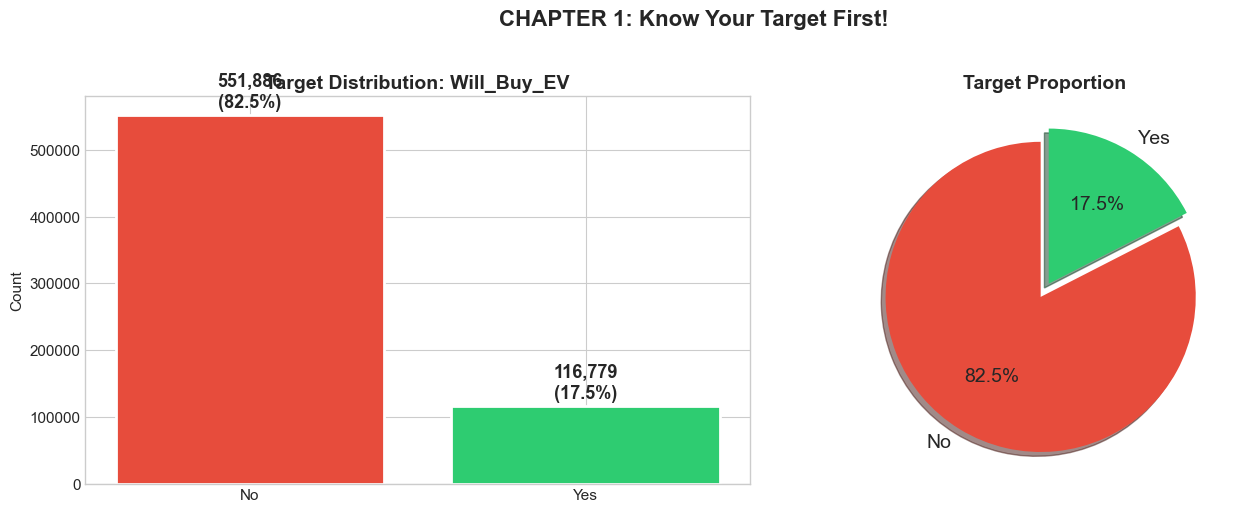


Imbalance Ratio: 4.7:1 (for every 1 buyer, there are 4.7 non-buyers)


In [6]:
# === TARGET DISTRIBUTION ===
# Create a numeric version of the target (needed for analysis)
train['target'] = (train['Will_Buy_EV'] == 'Yes').astype(int)

target_counts = train['Will_Buy_EV'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart - shows absolute numbers
colors = ['#e74c3c', '#2ecc71']
bars = axes[0].bar(target_counts.index, target_counts.values, color=colors,
                   edgecolor='white', linewidth=2)
axes[0].set_title('Target Distribution: Will_Buy_EV')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5000,
                f'{val:,}\n({val/len(train)*100:.1f}%)',
                ha='center', va='bottom', fontweight='bold', fontsize=13)

# Pie chart - shows proportions
axes[1].pie(target_counts.values, labels=target_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90,
            explode=(0.05, 0.05), shadow=True, textprops={'fontsize': 14})
axes[1].set_title('Target Proportion')

plt.suptitle('CHAPTER 1: Know Your Target First!', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

ratio = target_counts['No'] / target_counts['Yes']
print(f'\nImbalance Ratio: {ratio:.1f}:1 (for every 1 buyer, there are {ratio:.1f} non-buyers)')

### Target Imbalance Implications

> ~82.5% **No**     ~17.5% **Yes**     **Ratio is 4.7:1.**

| Decision | Wrong Choice | Right Choice | Why |
|----------|-------------|--------------|-----|
| **CV Strategy** | Regular KFold | **StratifiedKFold** | Each fold must maintain the 82.5/17.5 ratio |
| **Model Config** | Default weights | `scale_pos_weight=4.7` (XGB) or `is_unbalance=True` (LGB) | Tells the model that positive cases are more important |
| **Feature Focus** | Features that predict "No" | **Features that predict "Yes"** | Identifying the minority class is important |

---
## Numeric Feature Distributions

> 1. **Shape** — normal, skewed, uniform, bimodal?  
> 2. **Range** — are there outliers?  
> 3. **Separation** — does the distribution SHIFT between target classes?

### Class Separation Analysis
The most powerful trick in EDA: **overlay the distributions of target=Yes and target=No.**  
If they separate → the feature is predictive.  
If they overlap completely → the feature is weak.

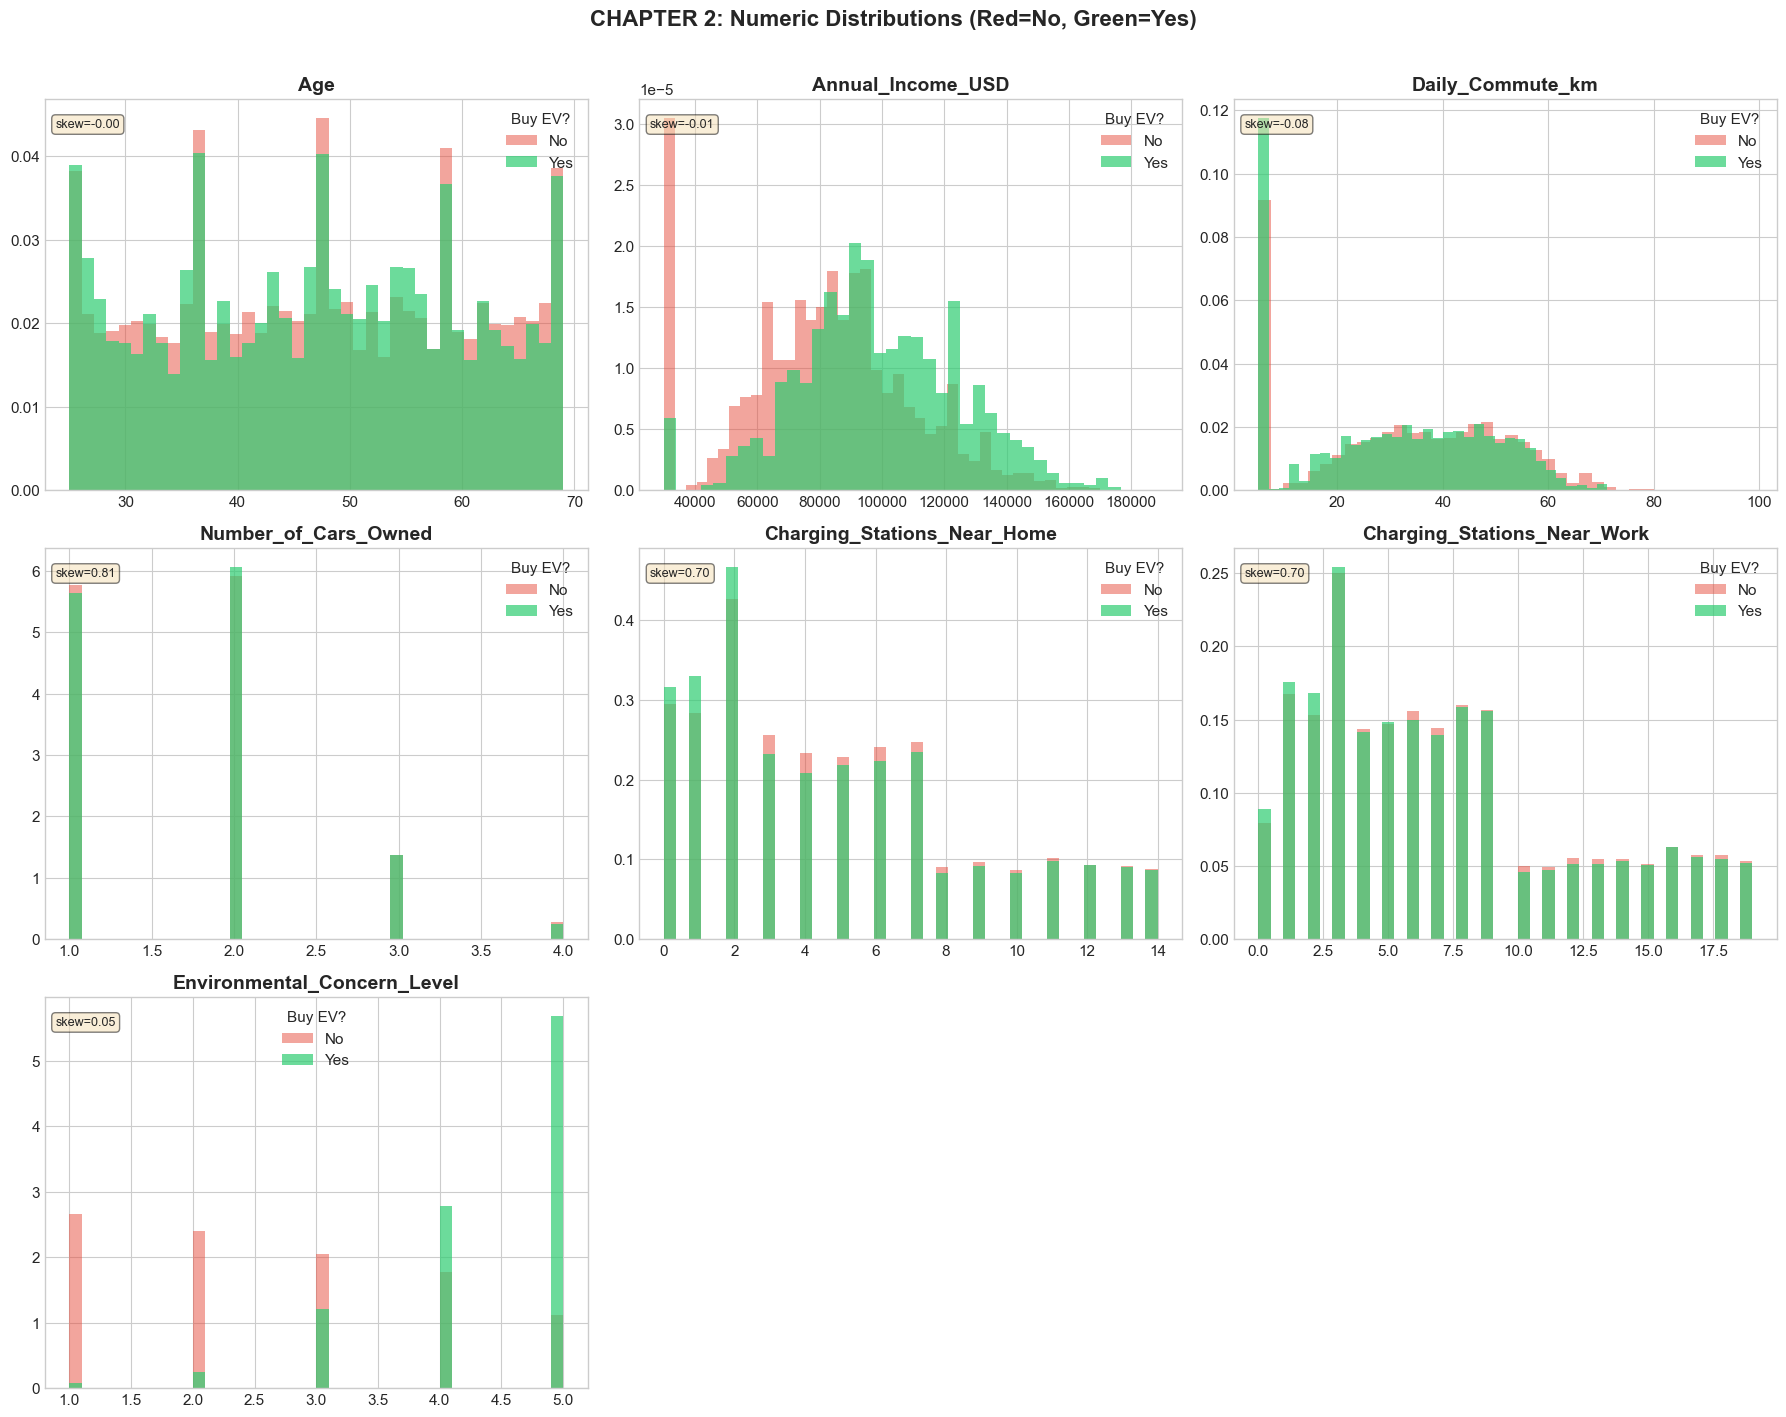

In [7]:
# === NUMERIC DISTRIBUTIONS COLORED BY TARGET ===
numeric_cols = ['Age', 'Annual_Income_USD', 'Daily_Commute_km',
                'Number_of_Cars_Owned', 'Charging_Stations_Near_Home',
                'Charging_Stations_Near_Work', 'Environmental_Concern_Level']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]

    # THE KEY TECHNIQUE: Plot both classes on the same axis
    for label, color, alpha in [('No', '#e74c3c', 0.5), ('Yes', '#2ecc71', 0.7)]:
        subset = train[train['Will_Buy_EV'] == label][col]
        ax.hist(subset, bins=40, alpha=alpha, color=color, label=label, density=True)

    ax.set_title(f'{col}', fontweight='bold')
    ax.legend(title='Buy EV?')

    # Add skewness - tells you if the distribution is lopsided
    skew = train[col].skew()
    ax.text(0.02, 0.95, f'skew={skew:.2f}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('CHAPTER 2: Numeric Distributions (Red=No, Green=Yes)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Numeric Distribution Insights

#### Question 1: "Does the green (Yes) shift away from the red (No)?"

| Feature | Shift? | What you see | Verdict |
|---------|--------|-------------|--------|
| **Environmental_Concern** | **YES — MASSIVE** | Green piles up at 4-5, Red piles up at 1-2 | **#1 PREDICTOR** |
| **Annual_Income** | **Yes — clear** | Green shifts right (higher income) | **Strong predictor** |
| **Daily_Commute** | Slight | Green slightly left (shorter commute) | Moderate |
| Age | No | Nearly identical shapes | **Weak** |
| Number_of_Cars | No | Nearly identical | **Weak** |
| Charging_Near_Home | No | Nearly identical | **Weak alone** |
| Charging_Near_Work | No | Nearly identical | **Weak alone** |

#### Question 2: "Is it skewed?"

| Feature | Skew | Action |
|---------|------|--------|
| Annual_Income | Slightly right-skewed | Try `log(income)` transform |
| Charging_Near_Work | Right-skewed (0.67) | Try `log` or `sqrt` transform |
| Age | ~0 (symmetric) | No transform needed |

#### Question 3: "Are there discrete jumps?"

| Feature | Pattern | Action |
|---------|---------|--------|
| Number_of_Cars | Only values 1-4 | **Treat as categorical** |
| Environmental_Concern | Only values 1-5 | **Ordinal categorical** |

---

> **Key Takeaways:** Environmental_Concern is clearly the #1 feature — the distributions barely overlap. Annual_Income is #2. Everything else needs INTERACTIONS to be useful.

---
## Categorical Target Rate Analysis

> **"Target rate by category"**  
> 
> This directly answers: "Does being in category X make the target more or less likely?"

### What is "Target Rate"?

```
Target Rate = (number of Yes) / (total in that category)

Example: Gender=Female
  295,427 females total
  52,491 of them bought EV (Yes)
  Target Rate = 52,491 / 295,427 = 17.8%
```

### How To Read The Chart
- **Red dashed line** = overall average (17.5%)
- Categories **RIGHT of the line** → INCREASE purchase probability
- Categories **LEFT of the line** → DECREASE purchase probability
- **FAR from the line** → Strong signal
- **Close to the line** → Weak signal

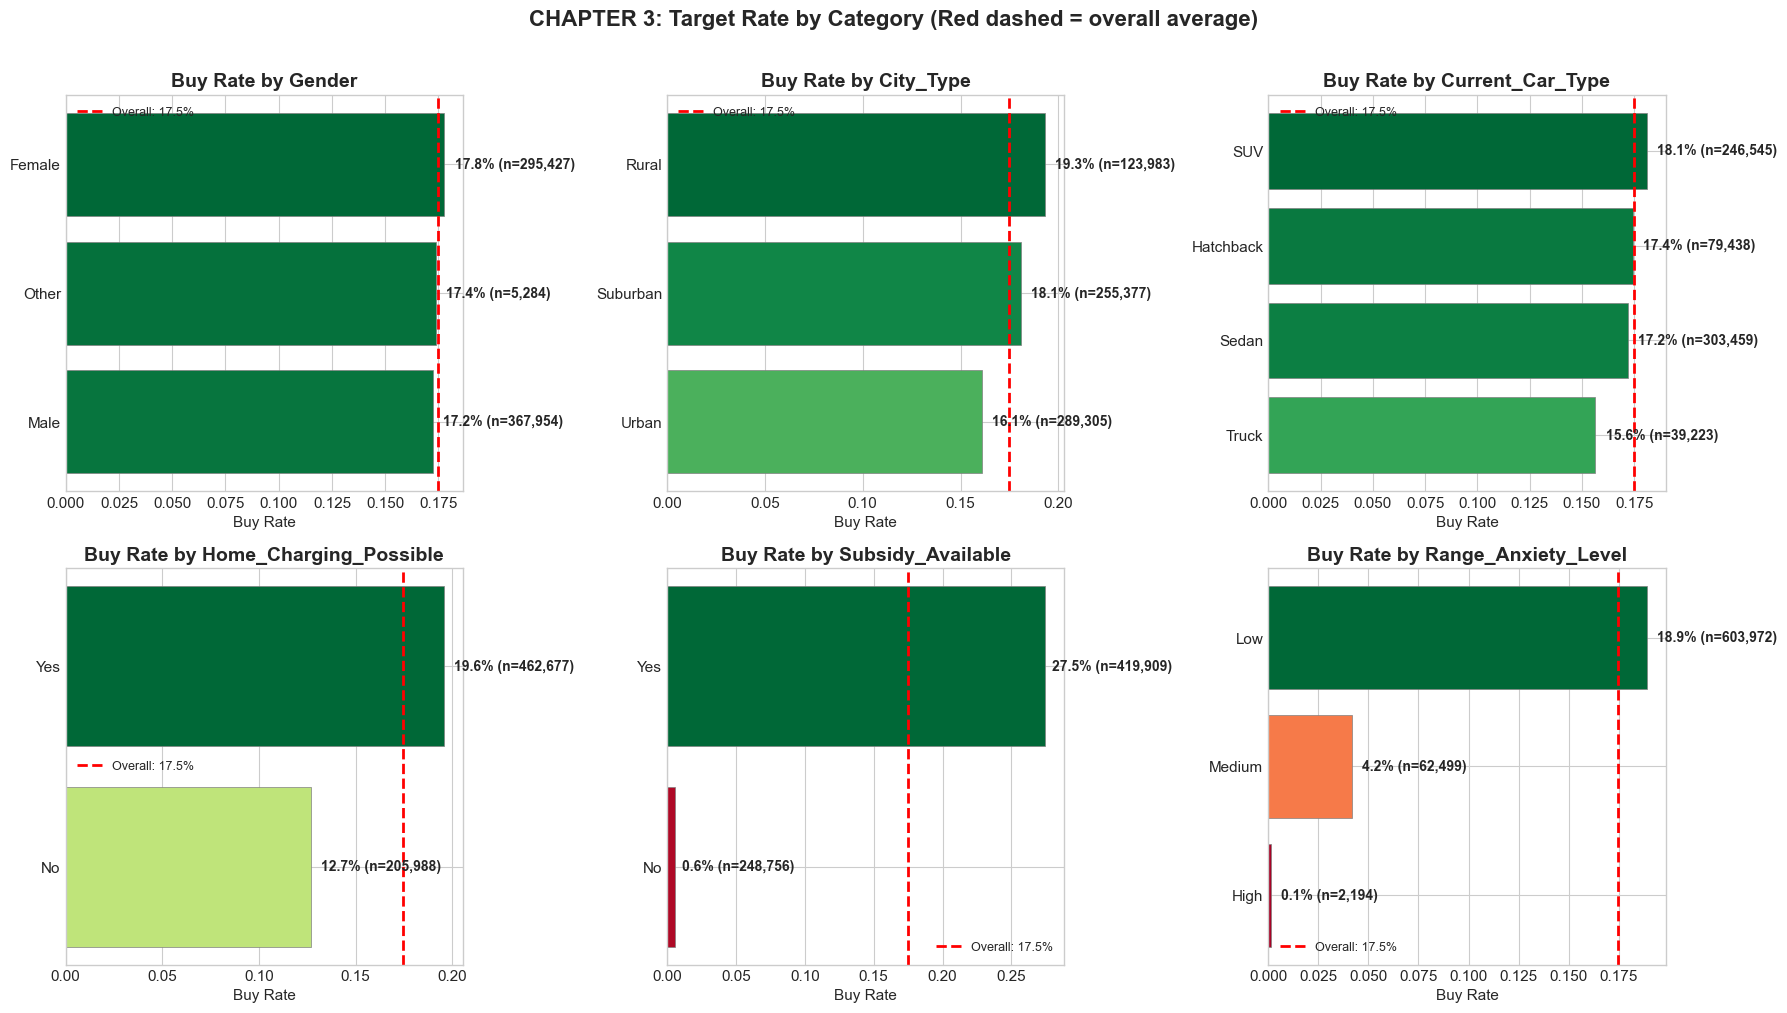

In [8]:
# === TARGET RATE BY EACH CATEGORICAL FEATURE ===
cat_cols = ['Gender', 'City_Type', 'Current_Car_Type',
            'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]

    # Calculate target rate per category
    rates = train.groupby(col)['target'].agg(['mean', 'count']).reset_index()
    rates.columns = [col, 'buy_rate', 'count']
    rates = rates.sort_values('buy_rate', ascending=True)

    # Horizontal bar chart — sorted by buy rate
    bars = ax.barh(rates[col], rates['buy_rate'],
                   color=plt.cm.RdYlGn(rates['buy_rate'] / max(rates['buy_rate'].max(), 0.01)),
                   edgecolor='gray', linewidth=0.5)

    # Add labels with rate AND sample size
    for bar, rate, count in zip(bars, rates['buy_rate'], rates['count']):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2.,
                f'{rate:.1%} (n={count:,})', va='center', fontsize=10, fontweight='bold')

    # RED DASHED LINE = overall average
    baseline = train['target'].mean()
    ax.axvline(x=baseline, color='red', linestyle='--', linewidth=2,
               label=f'Overall: {baseline:.1%}')

    ax.set_title(f'Buy Rate by {col}', fontweight='bold')
    ax.set_xlabel('Buy Rate')
    ax.legend(fontsize=9)

plt.suptitle('CHAPTER 3: Target Rate by Category (Red dashed = overall average)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Categorical Target Rate Findings

#### **Subsidy_Available** — THE GAME CHANGER
- **Yes: 27.5%** (far RIGHT of the average line)
- **No: 0.58%** (basically ZERO)

> **What this means:** Without a subsidy, almost NOBODY buys an EV.

#### **Range_Anxiety_Level** — STRONG ORDINAL
- **Low: 18.9%** → **Medium: 4.2%** → **High: 0.14%**

> **What this means:** Clear ordinal ordering! Encode as Low=0, Medium=1, High=2.

#### **Home_Charging_Possible** — MODERATE
- **Yes: 19.6%** vs **No: 12.7%**

> **What this means:** Having home charging helps, but it's not as extreme as Subsidy.

#### **Gender** — ALMOST USELESS
- All categories between 17.2% and 17.8%

> **What this means:** Gender barely moves the needle.

#### **City_Type & Current_Car_Type** — WEAK
- Small differences. Maybe useful in interactions.

---
## Feature Interactions — Finding Non-Linear Signals

### How To Read Interaction Heatmaps

- Each cell = buy rate for that **specific combination**
- **Green** = high buy rate
- **Red/Dark** = low buy rate
- If **all rows look the same** → No interaction (features are independent)
- If **rows look VERY different** → STRONG interaction! → **CREATE THIS AS A FEATURE!**

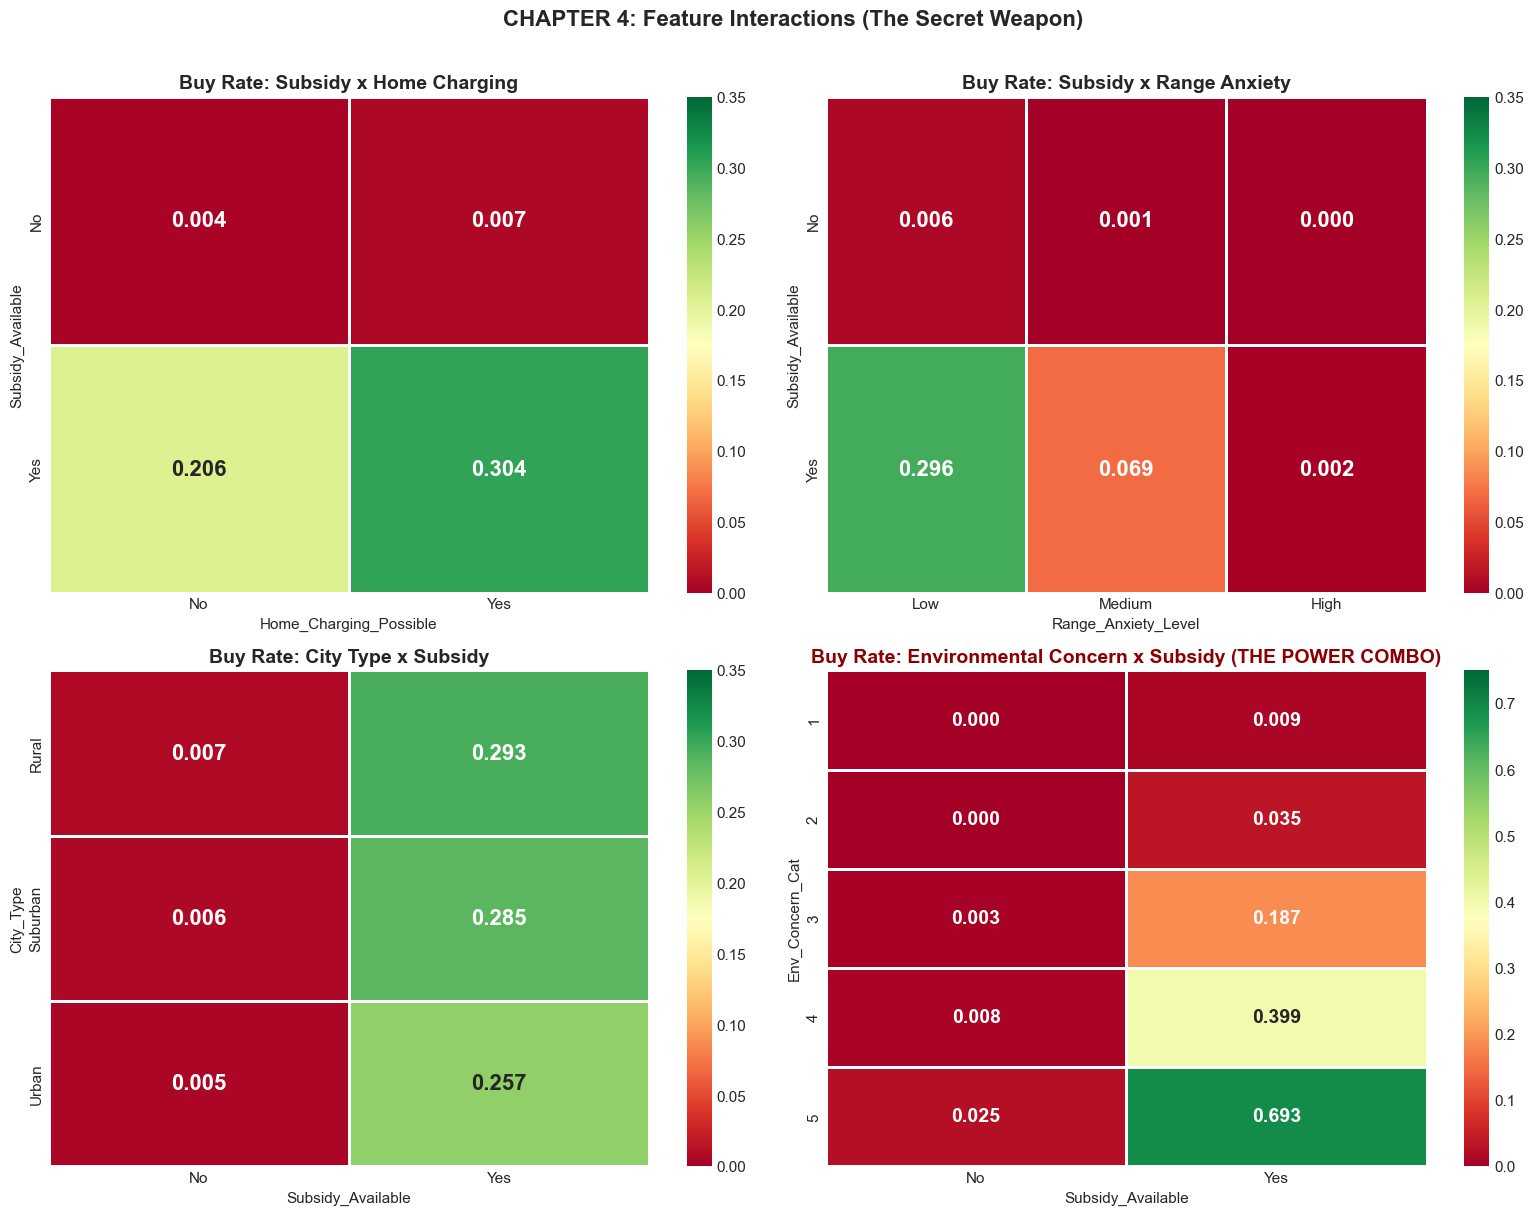

In [9]:
# === INTERACTION HEATMAPS ===
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- INTERACTION 1: Subsidy x Home Charging ---
ct1 = pd.crosstab(train['Subsidy_Available'], train['Home_Charging_Possible'],
                  values=train['target'], aggfunc='mean')
sns.heatmap(ct1, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[0, 0],
            linewidths=2, linecolor='white', annot_kws={'size': 16, 'weight': 'bold'},
            vmin=0, vmax=0.35)
axes[0, 0].set_title('Buy Rate: Subsidy x Home Charging', fontweight='bold')

# --- INTERACTION 2: Subsidy x Range Anxiety ---
ct2 = pd.crosstab(train['Subsidy_Available'], train['Range_Anxiety_Level'],
                  values=train['target'], aggfunc='mean')
ct2 = ct2[['Low', 'Medium', 'High']]  # Reorder logically
sns.heatmap(ct2, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[0, 1],
            linewidths=2, linecolor='white', annot_kws={'size': 16, 'weight': 'bold'},
            vmin=0, vmax=0.35)
axes[0, 1].set_title('Buy Rate: Subsidy x Range Anxiety', fontweight='bold')

# --- INTERACTION 3: City Type x Subsidy ---
ct3 = pd.crosstab(train['City_Type'], train['Subsidy_Available'],
                  values=train['target'], aggfunc='mean')
sns.heatmap(ct3, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[1, 0],
            linewidths=2, linecolor='white', annot_kws={'size': 16, 'weight': 'bold'},
            vmin=0, vmax=0.35)
axes[1, 0].set_title('Buy Rate: City Type x Subsidy', fontweight='bold')

# --- INTERACTION 4: Environmental Concern x Subsidy (THE BIG ONE) ---
train['Env_Concern_Cat'] = train['Environmental_Concern_Level'].astype(int).astype(str)
ct4 = pd.crosstab(train['Env_Concern_Cat'], train['Subsidy_Available'],
                  values=train['target'], aggfunc='mean')
sns.heatmap(ct4, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[1, 1],
            linewidths=2, linecolor='white', annot_kws={'size': 14, 'weight': 'bold'},
            vmin=0, vmax=0.75)
axes[1, 1].set_title('Buy Rate: Environmental Concern x Subsidy (THE POWER COMBO)',
                     fontweight='bold', color='darkred')

plt.suptitle('CHAPTER 4: Feature Interactions (The Secret Weapon)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Key Interaction: Environmental Concern & Subsidy

Look at the **bottom-right heatmap** (Environmental Concern x Subsidy):

| | Subsidy=No | Subsidy=Yes | Difference |
|---|---:|---:|---:|
| Concern=1 | 0.0% | 0.9% | +0.9% |
| Concern=2 | 0.0% | 3.5% | +3.5% |
| Concern=3 | 0.3% | 18.7% | +18.4% |
| Concern=4 | 0.8% | 39.9% | +39.1% |
| **Concern=5** | **2.5%** | **69.3%** | **+66.8%** |

#### What this tells us:

1. **Subsidy is a GATE:** Without it, the buy rate is near-zero regardless of concern level
2. **Environmental Concern amplifies Subsidy:** The gap between Subsidy=Yes and No GROWS with concern
3. **The "golden combination":** Concern=5 + Subsidy=Yes = **69.3% buy rate!**
4. **The "dead combination":** Concern=1 + Subsidy=No = **0.0% buy rate**

---
## Numeric Features vs Target (Box Plots)

> Small overlap between boxes = feature separates Yes and No well.  
> Large overlap = feature doesn't help distinguish.

**Key metric:** Look at the `Δmean` (% difference in means between Yes and No).  
- `|Δmean| > 10%` → Strong feature (shown in **green**)
- `|Δmean| < 10%` → Weak feature (shown in gray)

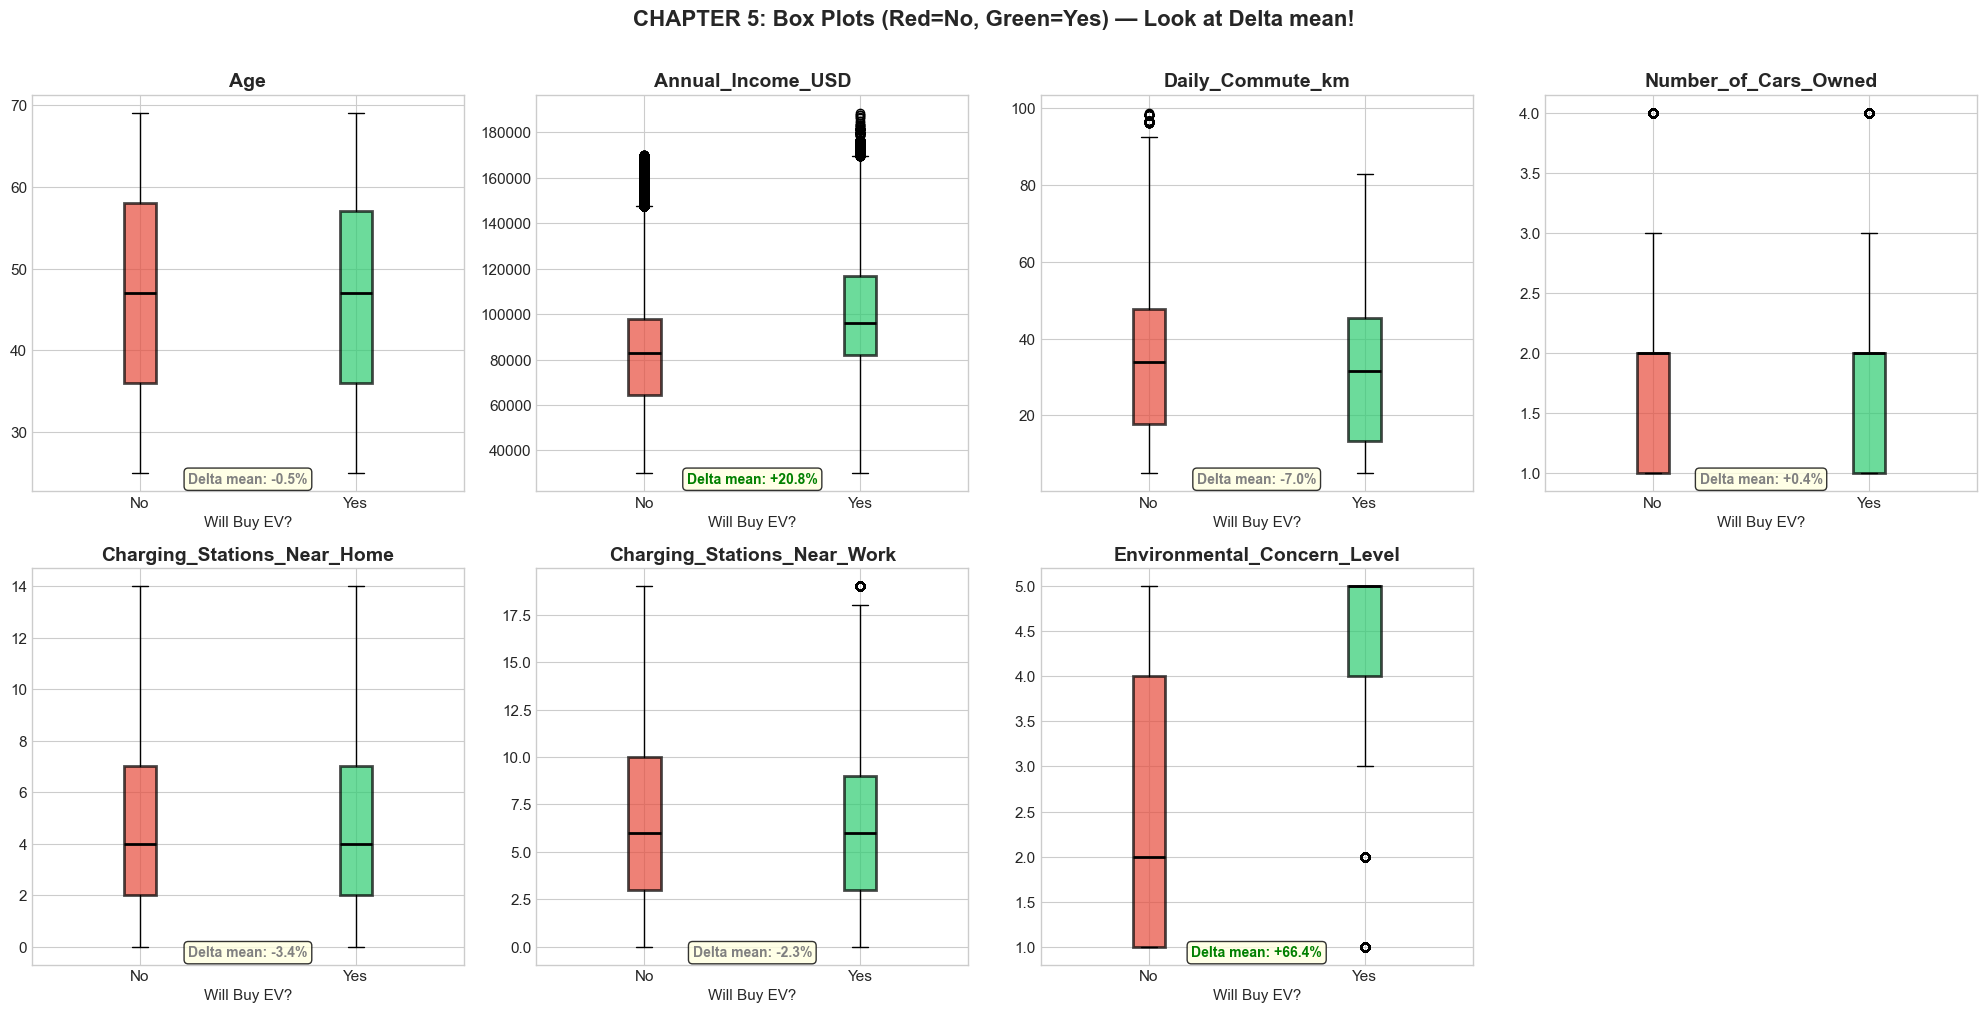

In [11]:
# === BOX PLOTS: Numeric Features vs Target ===
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]

    data_no = train[train['Will_Buy_EV'] == 'No'][col]
    data_yes = train[train['Will_Buy_EV'] == 'Yes'][col]

    bp = ax.boxplot([data_no, data_yes], labels=['No', 'Yes'],
                    patch_artist=True,
                    boxprops=dict(linewidth=2),
                    medianprops=dict(linewidth=2, color='black'))
    bp['boxes'][0].set_facecolor('#e74c3c')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#2ecc71')
    bp['boxes'][1].set_alpha(0.7)

    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel('Will Buy EV?')

    # Calculate and display the difference
    mean_no = data_no.mean()
    mean_yes = data_yes.mean()
    diff_pct = (mean_yes - mean_no) / mean_no * 100
    color = 'green' if abs(diff_pct) > 10 else 'gray'
    ax.text(0.5, 0.02, f'Delta mean: {diff_pct:+.1f}%', transform=ax.transAxes,
            ha='center', fontsize=10, fontweight='bold', color=color,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

fig.delaxes(axes[7])

plt.suptitle('CHAPTER 5: Box Plots (Red=No, Green=Yes) — Look at Delta mean!',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Class Separation Findings

| Feature | Delta mean | Meaning |
|---------|-------:|---------|
| **Environmental_Concern** | **+66.4%** | HUGE gap — the Green box sits much higher than Red |
| **Annual_Income** | **+20.8%** | Strong — buyers are clearly richer |
| Daily_Commute | -6.9% | Small, negative — long commuters buy LESS (range anxiety?) |
| Age | -0.5% | Nothing — age doesn't matter |
| Number_of_Cars | +0.4% | Nothing |
| Charging_Near_Home | -3.4% | Nearly nothing |
| Charging_Near_Work | -2.3% | Nearly nothing |

---
## Correlation Analysis

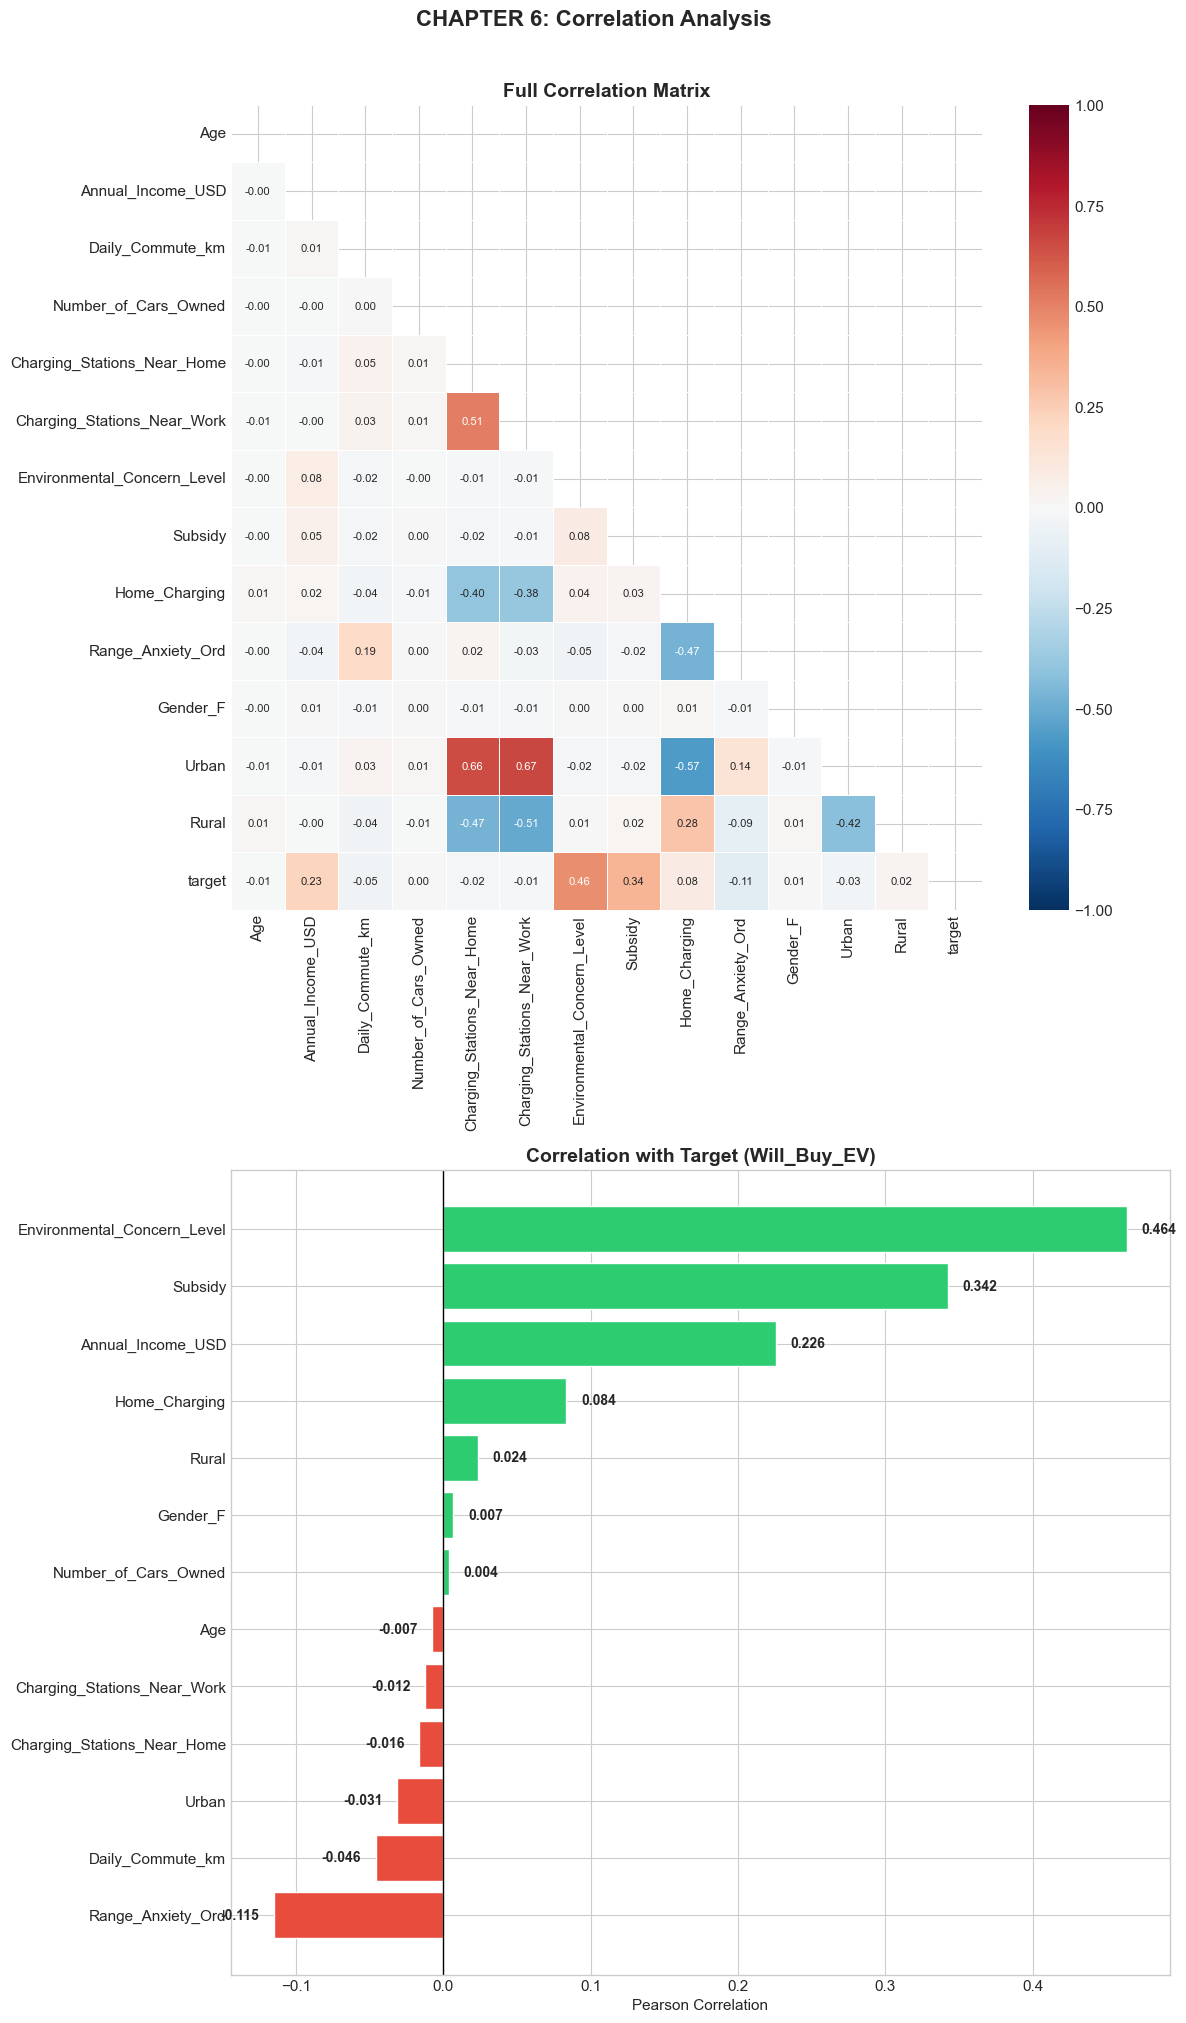

In [15]:
# === CORRELATION ANALYSIS ===
# First, encode categoricals so we can compute correlation
train_encoded = train.copy()
train_encoded['Subsidy'] = (train['Subsidy_Available'] == 'Yes').astype(int)
train_encoded['Home_Charging'] = (train['Home_Charging_Possible'] == 'Yes').astype(int)
train_encoded['Range_Anxiety_Ord'] = train['Range_Anxiety_Level'].map({'Low': 0, 'Medium': 1, 'High': 2})
train_encoded['Gender_F'] = (train['Gender'] == 'Female').astype(int)
train_encoded['Urban'] = (train['City_Type'] == 'Urban').astype(int)
train_encoded['Rural'] = (train['City_Type'] == 'Rural').astype(int)

corr_cols = ['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned',
             'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
             'Environmental_Concern_Level', 'Subsidy', 'Home_Charging',
             'Range_Anxiety_Ord', 'Gender_F', 'Urban', 'Rural', 'target']

corr_matrix = train_encoded[corr_cols].corr()

fig, axes = plt.subplots(2, 1, figsize=(12, 20))

# LEFT: Full correlation heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[0], linewidths=0.5, annot_kws={'size': 8},
            vmin=-1, vmax=1)
axes[0].set_title('Full Correlation Matrix', fontweight='bold')

# RIGHT: Target correlation bar chart (MOST USEFUL!)
target_corr = corr_matrix['target'].drop('target').sort_values()
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
axes[1].axvline(x=0, color='black', linewidth=1)
axes[1].set_title('Correlation with Target (Will_Buy_EV)', fontweight='bold')
axes[1].set_xlabel('Pearson Correlation')

for idx, (val, name) in enumerate(zip(target_corr.values, target_corr.index)):
    axes[1].text(val + (0.01 if val > 0 else -0.01), idx, f'{val:.3f}',
                va='center', ha='left' if val > 0 else 'right',
                fontweight='bold', fontsize=10)

plt.suptitle('CHAPTER 6: Correlation Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Correlation Insights

**Scale:**
- `+1.0` = Perfect positive (feature goes up → target goes up)
- `-1.0` = Perfect negative (feature goes up → target goes down)
- `0.0` = No LINEAR relationship (might still have non-linear!)

**Feature Ranking by Target Correlation:**

| Rank | Feature | Correlation | Strength |
|------|---------|------------|----------|
| 1 | Environmental_Concern | +0.464 | STRONG |
| 2 | Subsidy | +0.342 | STRONG |
| 3 | Annual_Income | +0.226 | MODERATE |
| 4 | Range_Anxiety (ordinal) | -0.115 | MODERATE (negative) |
| 5 | Home_Charging | +0.084 | WEAK |
| 6-13 | Everything else | <0.05 | VERY WEAK |

---
## Deep Dive Into the Top Feature

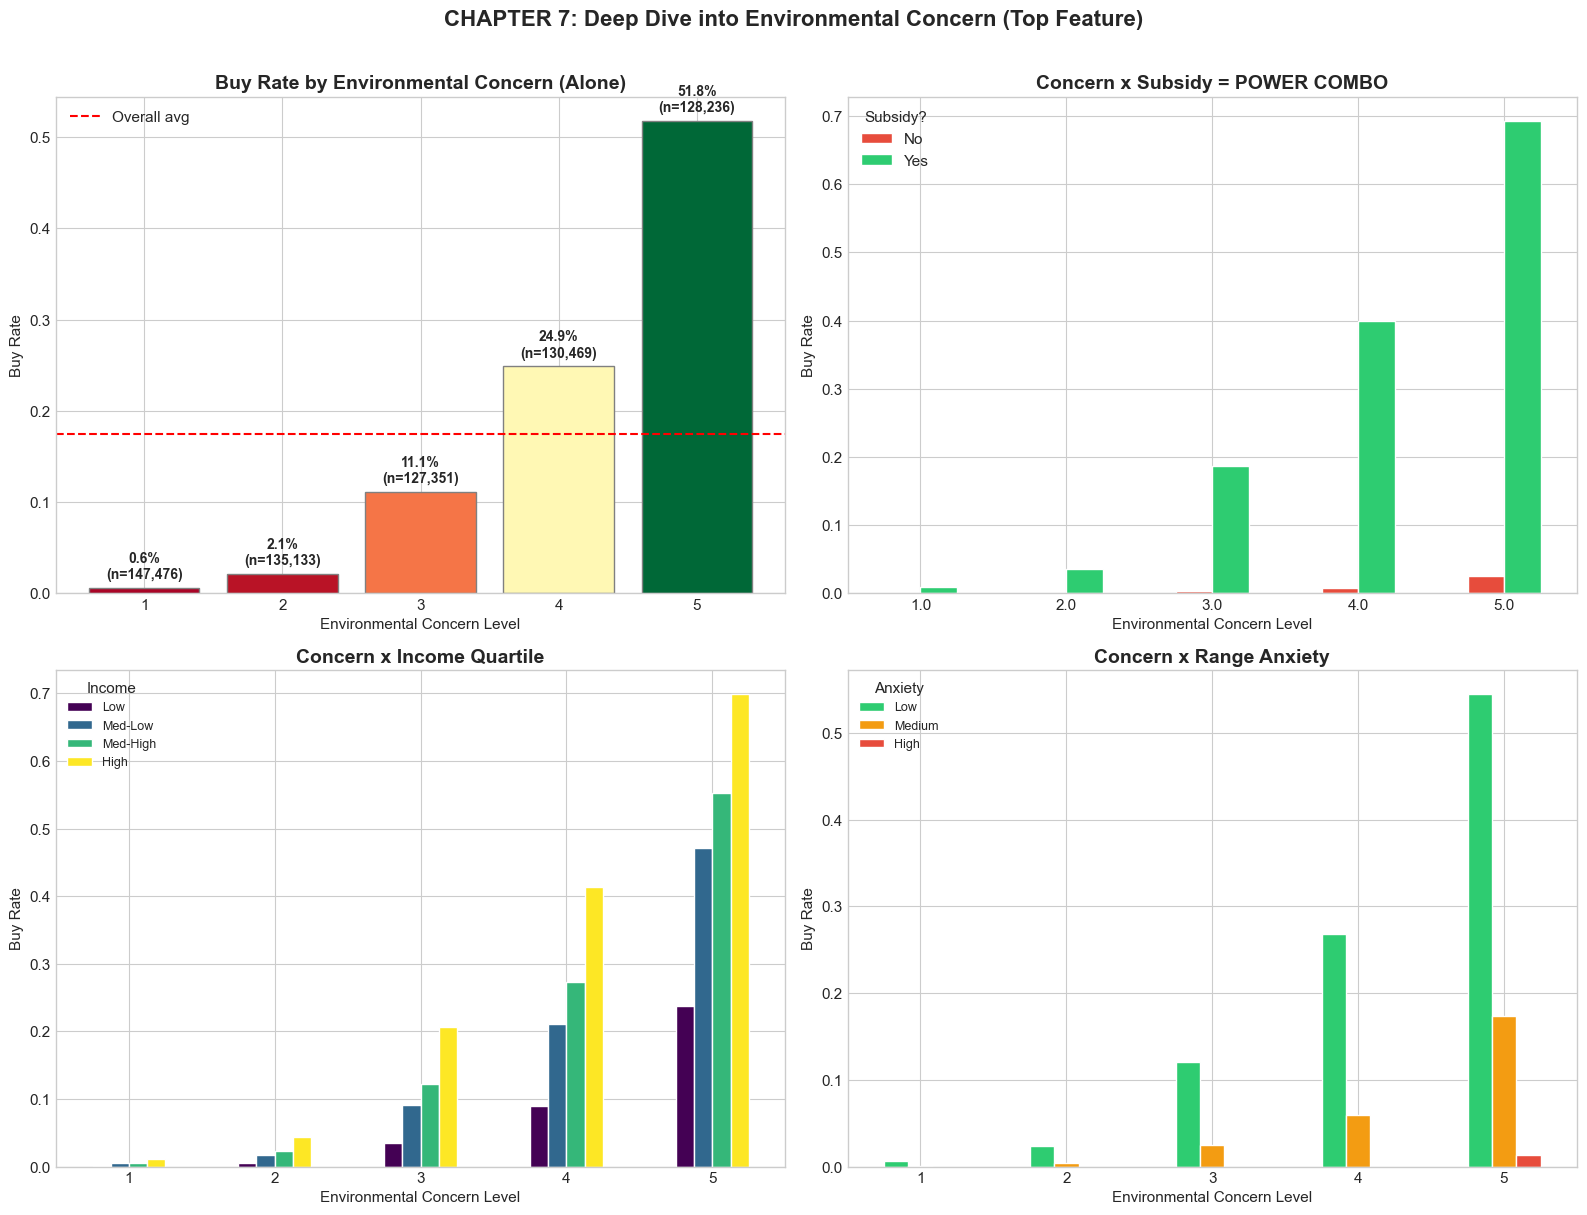

In [16]:
# === DEEP DIVE: Environmental Concern Level ===
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# PLOT 1: Buy rate by concern level (alone)
concern_rates = train.groupby('Environmental_Concern_Level')['target'].agg(['mean', 'count']).reset_index()
bars = axes[0, 0].bar(concern_rates['Environmental_Concern_Level'],
                       concern_rates['mean'],
                       color=plt.cm.RdYlGn(concern_rates['mean'] / concern_rates['mean'].max()),
                       edgecolor='gray')
for bar, rate, count in zip(bars, concern_rates['mean'], concern_rates['count']):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{rate:.1%}\n(n={count:,})', ha='center', fontweight='bold', fontsize=10)
axes[0, 0].set_xlabel('Environmental Concern Level')
axes[0, 0].set_ylabel('Buy Rate')
axes[0, 0].set_title('Buy Rate by Environmental Concern (Alone)', fontweight='bold')
axes[0, 0].axhline(y=train['target'].mean(), color='red', linestyle='--', label='Overall avg')
axes[0, 0].legend()

# PLOT 2: Concern x Subsidy (the POWER COMBO)
concern_subsidy = train.groupby(['Environmental_Concern_Level', 'Subsidy_Available'])['target'].mean().unstack()
concern_subsidy.plot(kind='bar', ax=axes[0, 1], color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[0, 1].set_title('Concern x Subsidy = POWER COMBO', fontweight='bold')
axes[0, 1].set_xlabel('Environmental Concern Level')
axes[0, 1].set_ylabel('Buy Rate')
axes[0, 1].legend(title='Subsidy?')
axes[0, 1].tick_params(axis='x', rotation=0)

# PLOT 3: Concern x Income quartile
income_bins = pd.qcut(train['Annual_Income_USD'], 4, labels=['Low', 'Med-Low', 'Med-High', 'High'])
concern_income = train.groupby([train['Environmental_Concern_Level'].astype(int), income_bins])['target'].mean().unstack()
concern_income.plot(kind='bar', ax=axes[1, 0], colormap='viridis', edgecolor='white')
axes[1, 0].set_title('Concern x Income Quartile', fontweight='bold')
axes[1, 0].set_xlabel('Environmental Concern Level')
axes[1, 0].set_ylabel('Buy Rate')
axes[1, 0].legend(title='Income', fontsize=9)
axes[1, 0].tick_params(axis='x', rotation=0)

# PLOT 4: Concern x Range Anxiety
concern_anxiety = train.groupby([train['Environmental_Concern_Level'].astype(int), 'Range_Anxiety_Level'])['target'].mean().unstack()
concern_anxiety = concern_anxiety[['Low', 'Medium', 'High']]
concern_anxiety.plot(kind='bar', ax=axes[1, 1], color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='white')
axes[1, 1].set_title('Concern x Range Anxiety', fontweight='bold')
axes[1, 1].set_xlabel('Environmental Concern Level')
axes[1, 1].set_ylabel('Buy Rate')
axes[1, 1].legend(title='Anxiety', fontsize=9)
axes[1, 1].tick_params(axis='x', rotation=0)

plt.suptitle('CHAPTER 7: Deep Dive into Environmental Concern (Top Feature)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Advanced Feature Insights

#### Finding 1: The Exponential Curve (Top-Left)

| Concern | Buy Rate | Jump from previous |
|:---:|---:|---:|
| 1 | 0.6% | — |
| 2 | 2.1% | x3.7 |
| 3 | 11.1% | x5.2 |
| 4 | 24.9% | x2.2 |
| 5 | 51.8% | x2.1 |

This is **NOT linear!** Each step roughly multiplies the rate.  

→ **`Concern_squared = Concern^2`** to capture this curve.

#### Finding 2: Subsidy Amplifies Everything (Top-Right)
The green bars (Subsidy=Yes) grow exponentially, while red bars (Subsidy=No) stay flat near zero.

→ **`Subsidy * Concern` interaction.**

#### Finding 3: Income Amplifies Concern (Bottom-Left)
At Concern=5: High Income = ~67% vs Low Income = ~35%.  

→ **`Income * Concern` interaction.**

#### Finding 4: High Anxiety is a VETO (Bottom-Right)
Even at Concern=5, High Anxiety kills purchase (~3%).  

→ Range Anxiety acts as a "veto" — if high, nothing else matters.

---
## Income Analysis — Finding Golden Segments

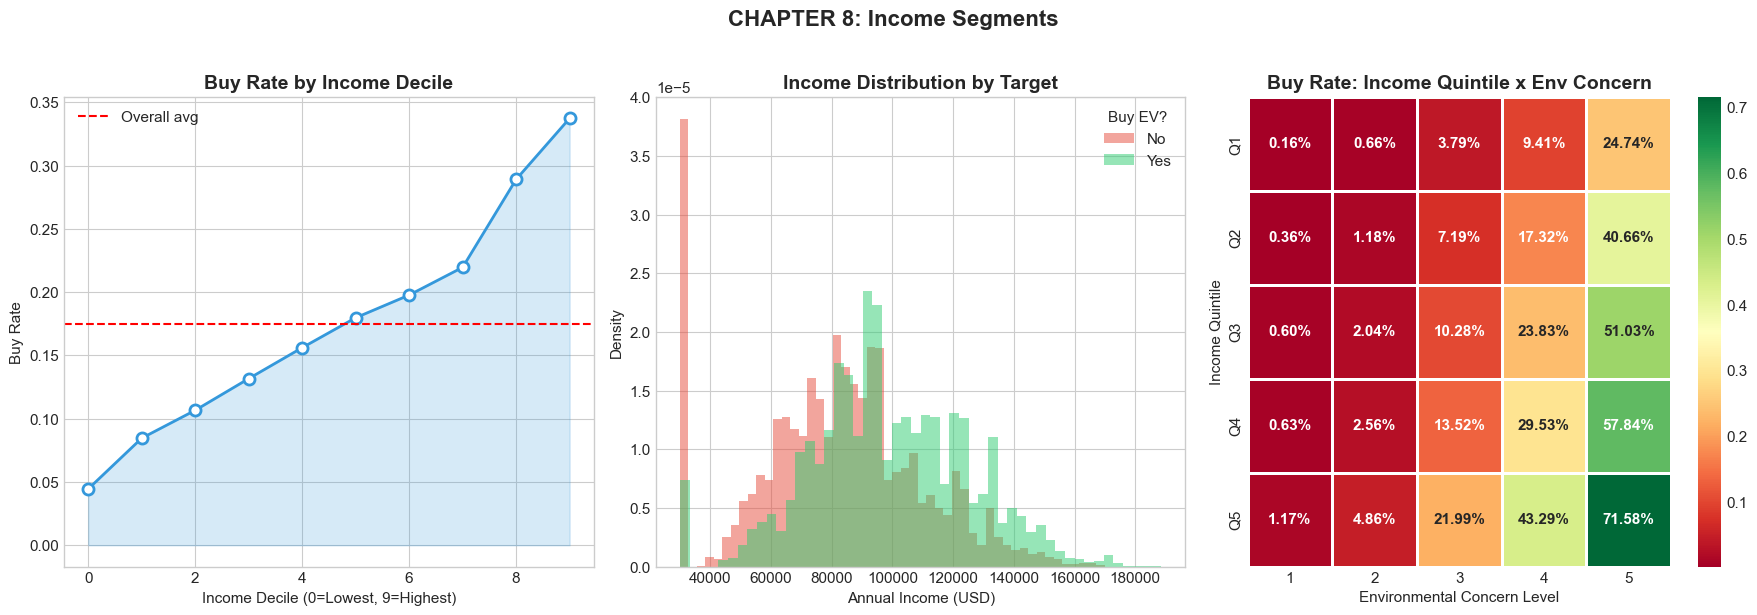

In [17]:
# === INCOME ANALYSIS ===
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# PLOT 1: Buy rate by income decile (is it linear?)
train['income_decile'] = pd.qcut(train['Annual_Income_USD'], 10, labels=False)
income_rates = train.groupby('income_decile')['target'].mean()

axes[0].plot(income_rates.index, income_rates.values, 'o-', color='#3498db',
             linewidth=2, markersize=8, markerfacecolor='white', markeredgewidth=2)
axes[0].fill_between(income_rates.index, income_rates.values, alpha=0.2, color='#3498db')
axes[0].axhline(y=train['target'].mean(), color='red', linestyle='--', label='Overall avg')
axes[0].set_xlabel('Income Decile (0=Lowest, 9=Highest)')
axes[0].set_ylabel('Buy Rate')
axes[0].set_title('Buy Rate by Income Decile', fontweight='bold')
axes[0].legend()

# PLOT 2: Income distribution colored by target
for label, color in [('No', '#e74c3c'), ('Yes', '#2ecc71')]:
    subset = train[train['Will_Buy_EV'] == label]['Annual_Income_USD']
    axes[1].hist(subset, bins=50, alpha=0.5, color=color, label=label, density=True)
axes[1].set_xlabel('Annual Income (USD)')
axes[1].set_ylabel('Density')
axes[1].set_title('Income Distribution by Target', fontweight='bold')
axes[1].legend(title='Buy EV?')

# PLOT 3: Income x Concern (the 2D golden segment finder)
train['income_q5'] = pd.qcut(train['Annual_Income_USD'], 5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
income_concern = pd.crosstab(train['income_q5'],
                              train['Environmental_Concern_Level'].astype(int),
                              values=train['target'], aggfunc='mean')
sns.heatmap(income_concern, annot=True, fmt='.2%', cmap='RdYlGn', ax=axes[2],
            linewidths=1, linecolor='white', annot_kws={'size': 11, 'weight': 'bold'})
axes[2].set_title('Buy Rate: Income Quintile x Env Concern', fontweight='bold')
axes[2].set_xlabel('Environmental Concern Level')
axes[2].set_ylabel('Income Quintile')

plt.suptitle('CHAPTER 8: Income Segments', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Income Insights

1. **Left plot:** Buy rate rises monotonically with income, but it **curves** (not linear) 
   → `log(income)` or `sqrt(income)` might work better

2. **Right heatmap — the GOLDEN SEGMENT map:**
   - Q5 (top income) + Concern=5: ~68% buy rate!
   - Q1 (low income) + Concern=1: ~0.3%
   - The spread is **200x** between best and worst!

---
## Proving Our EDA — The Buyer Score

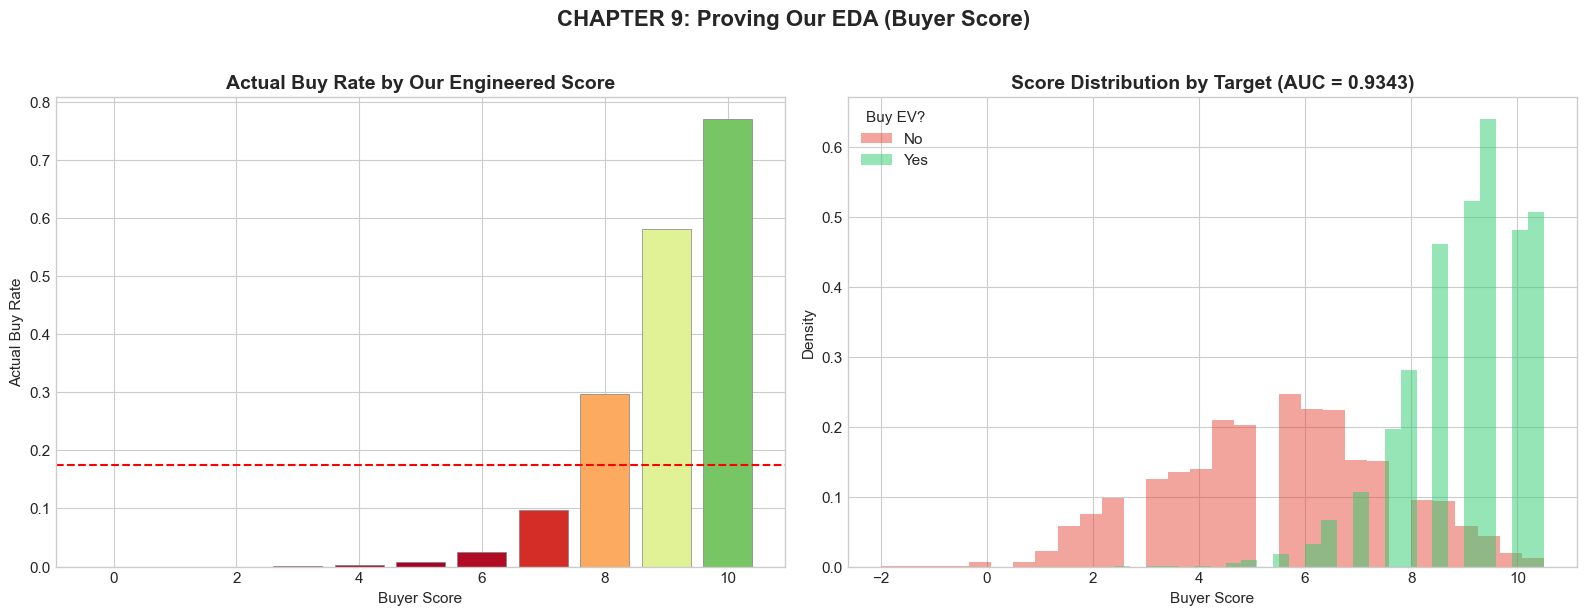


Buyer Score AUC: 0.9343

This single hand-crafted feature achieves AUC = 0.9343!
This PROVES our EDA insights are correct and actionable.
A proper model with all features + interactions should do even better.


In [18]:
# === THE BUYER SCORE: Combining Our EDA Insights ===
from sklearn.metrics import roc_auc_score

# Build a score based on what we learned:
buyer_score = pd.Series(0.0, index=train.index)

# Factor 1: Environmental Concern (our #1 feature, exponential effect)
buyer_score += train['Environmental_Concern_Level']

# Factor 2: Subsidy (the GATE - biggest single impact)
buyer_score += (train['Subsidy_Available'] == 'Yes').astype(int) * 3

# Factor 3: Income (normalized 0-2)
buyer_score += pd.qcut(train['Annual_Income_USD'], 5, labels=False) * 0.5

# Factor 4: Range Anxiety (negative effect - "veto" factor)
anxiety_map = {'Low': 0, 'Medium': -1, 'High': -3}
buyer_score += train['Range_Anxiety_Level'].map(anxiety_map)

# Factor 5: Home Charging (small positive)
buyer_score += (train['Home_Charging_Possible'] == 'Yes').astype(int) * 0.5

# Calculate AUC
auc = roc_auc_score(train['target'], buyer_score)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Buy rate by score bucket
train['buyer_score'] = buyer_score
score_rates = train.groupby(train['buyer_score'].round(0))['target'].agg(['mean', 'count']).reset_index()
score_rates.columns = ['score', 'rate', 'count']
score_rates = score_rates[score_rates['count'] > 100]

axes[0].bar(score_rates['score'], score_rates['rate'],
            color=plt.cm.RdYlGn(score_rates['rate']),
            edgecolor='gray', linewidth=0.5)
axes[0].set_xlabel('Buyer Score')
axes[0].set_ylabel('Actual Buy Rate')
axes[0].set_title('Actual Buy Rate by Our Engineered Score', fontweight='bold')
axes[0].axhline(y=train['target'].mean(), color='red', linestyle='--')

# RIGHT: Separation quality
for label, color in [('No', '#e74c3c'), ('Yes', '#2ecc71')]:
    subset = train[train['Will_Buy_EV'] == label]['buyer_score']
    axes[1].hist(subset, bins=30, alpha=0.5, color=color, label=label, density=True)
axes[1].set_xlabel('Buyer Score')
axes[1].set_ylabel('Density')
axes[1].set_title(f'Score Distribution by Target (AUC = {auc:.4f})', fontweight='bold')
axes[1].legend(title='Buy EV?')

plt.suptitle('CHAPTER 9: Proving Our EDA (Buyer Score)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nBuyer Score AUC: {auc:.4f}')
print(f'\nThis single hand-crafted feature achieves AUC = {auc:.4f}!')
print('This PROVES our EDA insights are correct and actionable.')
print('A proper model with all features + interactions should do even better.')

---
## Train vs Test Distribution Check

### What To Look For:
- **Histograms match** → Safe, your CV score is reliable
- **Histograms differ** → Danger! Need adversarial validation or time-based splits

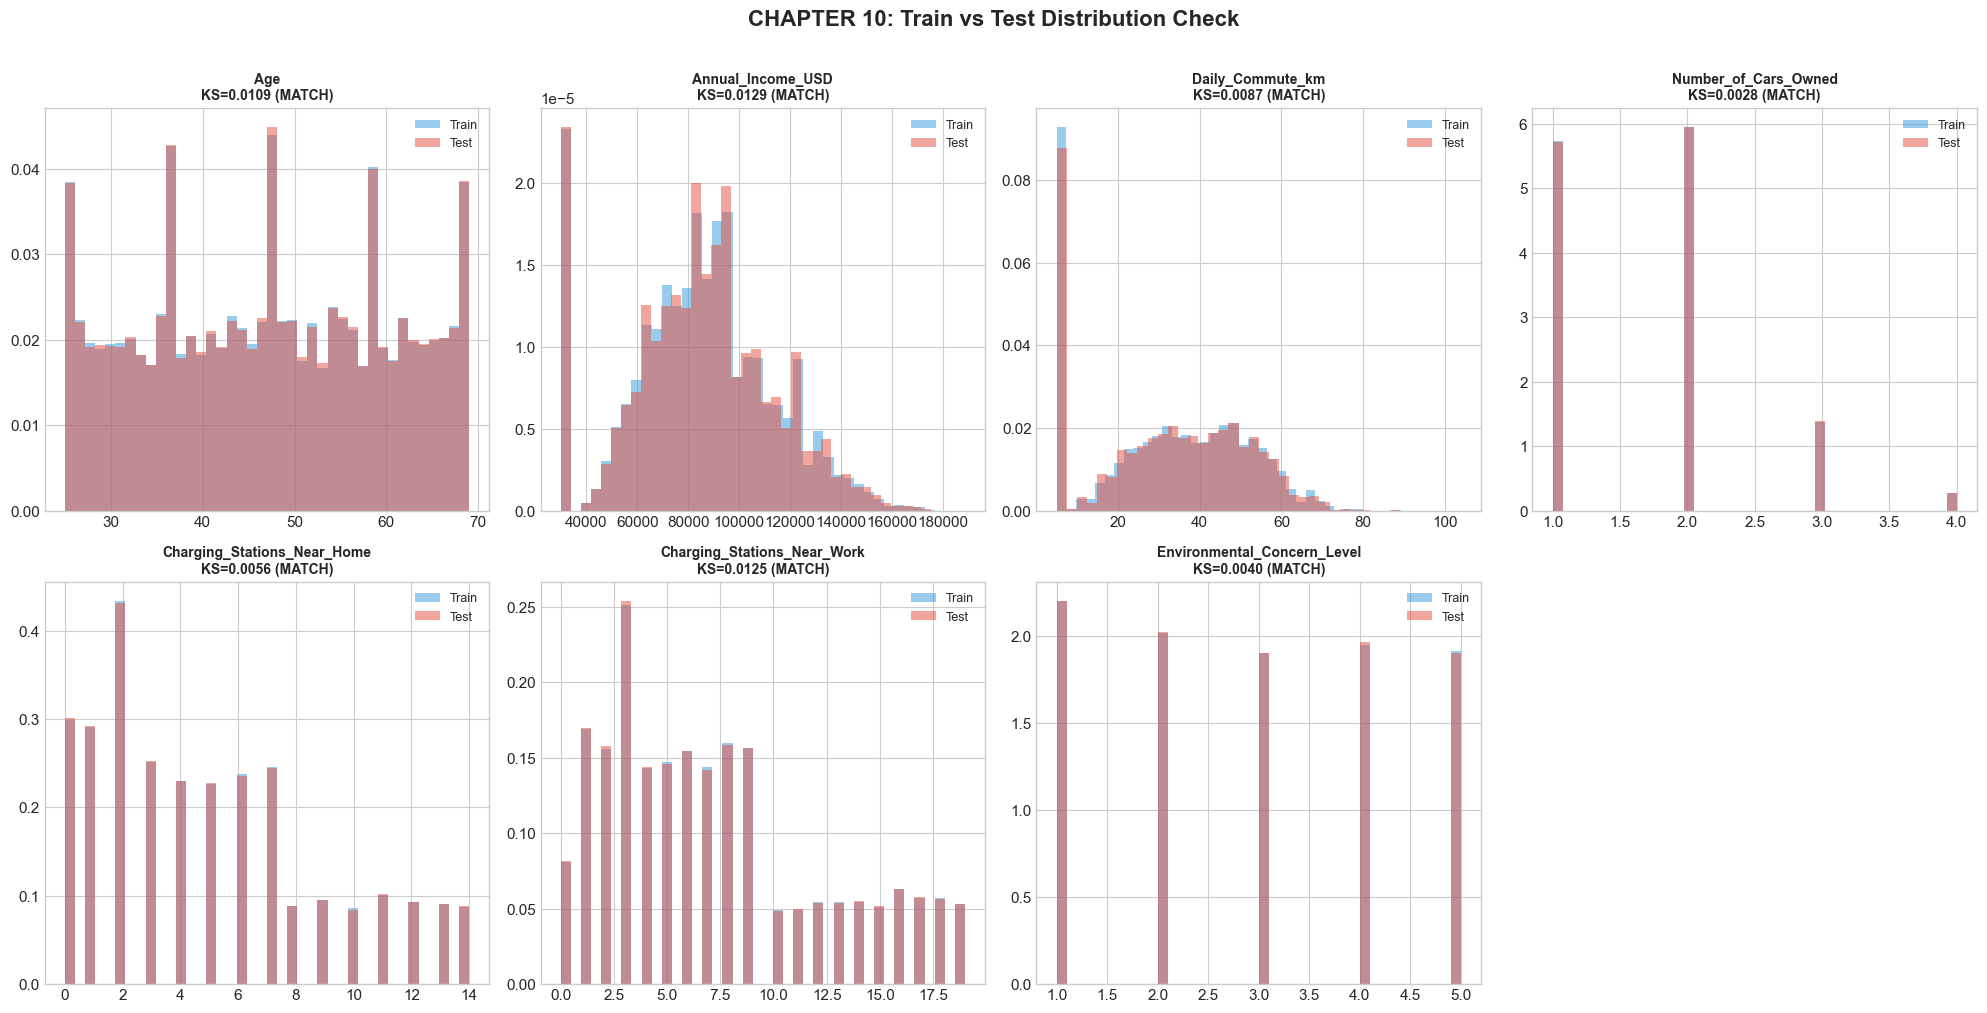


Categorical Distribution Comparison (Train vs Test):
  Gender                         max_diff=0.0002 [OK]
  City_Type                      max_diff=0.0013 [OK]
  Current_Car_Type               max_diff=0.0007 [OK]
  Home_Charging_Possible         max_diff=0.0007 [OK]
  Subsidy_Available              max_diff=0.0015 [OK]
  Range_Anxiety_Level            max_diff=0.0017 [OK]


In [21]:
# === TRAIN vs TEST DISTRIBUTIONS ===
test_df = pd.read_csv('dataset/test.csv')

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    ax.hist(train[col], bins=40, alpha=0.5, color='#3498db', label='Train', density=True)
    ax.hist(test_df[col], bins=40, alpha=0.5, color='#e74c3c', label='Test', density=True)

    # KS test: measures how different two distributions are
    ks_stat, ks_pval = stats.ks_2samp(
        train[col].sample(10000, random_state=42),
        test_df[col].sample(10000, random_state=42)
    )

    status = 'MATCH' if ks_pval > 0.05 else 'DIFFER!'
    ax.set_title(f'{col}\nKS={ks_stat:.4f} ({status})', fontweight='bold', fontsize=10)
    ax.legend(fontsize=9)

fig.delaxes(axes[7])

plt.suptitle('CHAPTER 10: Train vs Test Distribution Check',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Also check categoricals
print('\nCategorical Distribution Comparison (Train vs Test):')
cat_cols_check = ['Gender', 'City_Type', 'Current_Car_Type',
                  'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']
for col in cat_cols_check:
    train_dist = train[col].value_counts(normalize=True).sort_index()
    test_dist = test_df[col].value_counts(normalize=True).sort_index()
    max_diff = (train_dist - test_dist).abs().max()
    status = 'OK' if max_diff < 0.01 else 'CHECK!'
    print(f'  {col:30s} max_diff={max_diff:.4f} [{status}]')

### Train/Test Check Results

All distributions are virtually identical between train and test.

**What this means:**
- Local CV score will reliably predict LB score
- No need for adversarial validation
- Standard StratifiedKFold is fine

---
## Feature Engineering — Turning Insights Into Code

### The Tiered Approach

| Tier | Impact | Description |
|------|--------|-------------|
| **TIER 1** | HIGH | Must create. Directly from strongest EDA findings |
| **TIER 2** | MEDIUM | Should create. Combinations and transforms |
| **TIER 3** | LOW | Nice to have. Small gains, test if they help |

In [ ]:
from scipy.sparse import _construct
# === FEATURE ENGINEERING FUNCTION ===

def engineer_features(df):
    """Transform raw data into predictive features based on our EDA."""
    out = df.copy()

    # --- ENCODE CATEGORICALS ---
    out['Subsidy'] = (df['Subsidy_Available'] == 'Yes').astype(int)
    out['Home_Charging'] = (df['Home_Charging_Possible'] == 'Yes').astype(int)
    out['Range_Anxiety_Ord'] = df['Range_Anxiety_Level'].map(
        {'Low': 0, 'Medium': 1, 'High': 2}
    )

    # --- TIER 1: HIGH IMPACT (from Chapters 4, 7) ---
    # From Chapter 4: The POWER COMBO (69.3% buy rate at max!)
    out['Subsidy_x_EnvConcern'] = out['Subsidy'] * df['Environmental_Concern_Level']

    # From Chapter 7: Exponential curve -> need squared term
    out['EnvConcern_sq'] = df['Environmental_Concern_Level'] ** 2

    # From Chapter 8: Income amplifies concern
    out['Income_x_Concern'] = np.log1p(df['Annual_Income_USD']) * df['Environmental_Concern_Level']

    # --- TIER 2: MEDIUM IMPACT (from Chapters 5, 6, 7) ---
    # From Chapter 6: Charging stations are correlated with each other
    out['Total_Charging'] = df['Charging_Stations_Near_Home'] + df['Charging_Stations_Near_Work']
    out['Charging_Ratio'] = df['Charging_Stations_Near_Home'] / (out['Total_Charging'] + 1)

    # From Chapter 7: Composite readiness (Subsidy gates, Concern drives, Anxiety vetoes)
    out['Ready_Score'] = (out['Subsidy'] *
                          df['Environmental_Concern_Level'] *
                          (1 - out['Range_Anxiety_Ord'] / 2))

    # --- TIER 3: NICE TO HAVE (from Chapter 8) ---
    out['log_income'] = np.log1p(df['Annual_Income_USD'])
    out['Subsidy_x_HomeCharging'] = out['Subsidy'] * out['Home_Charging']
    out['Income_per_Car'] = df['Annual_Income_USD'] / df['Number_of_Cars_Owned']
    out['Commute_x_Anxiety'] = df['Daily_Commute_km'] * out['Range_Anxiety_Ord']

    # --- EXTRA INTERACTIONS ---
    out['Subsidy_x_Income'] = out['Subsidy'] * df['Annual_Income_USD']
    out['Concern_x_NoAnxiety'] = df['Environmental_Concern_Level'] * (2 - out['Range_Anxiety_Ord'])
    out['High_Concern_High_Income'] = (
        (df['Environmental_Concern_Level'] >= 4) &
        (df['Annual_Income_USD'] > df['Annual_Income_USD'].median())
    ).astype(int)

    out['buyer_score'] = 0.0
    # Factor 1: Environmental Concern (our #1 feature, exponential effect)
    out['buyer_score'] += df['Environmental_Concern_Level']

    # Factor 2: Subsidy (the GATE - biggest single impact)
    out['buyer_score'] += (df['Subsidy_Available'] == 'Yes').astype(int) * 3

    # Factor 3: Income (normalized 0-2)
    out['buyer_score'] += pd.qcut(df['Annual_Income_USD'], 5, labels=False) * 0.5

    # Factor 4: Range Anxiety (negative effect - "veto" factor)
    anxiety_map = {'Low': 0, 'Medium': -2, 'High': -5}
    out['buyer_score'] += df['Range_Anxiety_Level'].map(anxiety_map)

    # Factor 5: Home Charging (small positive)
    out['buyer_score'] += (df['Home_Charging_Possible'] == 'Yes').astype(int) * 0.5

    return out

# Apply to both train and test
train_fe = engineer_features(train)
test_fe = engineer_features(test_df)

print(f'Original features:    {train.shape[1]}')
print(f'Engineered features:  {train_fe.shape[1]}')
print(f'New features created: {train_fe.shape[1] - train.shape[1]}')

Original features:    20
Engineered features:  36
New features created: 16


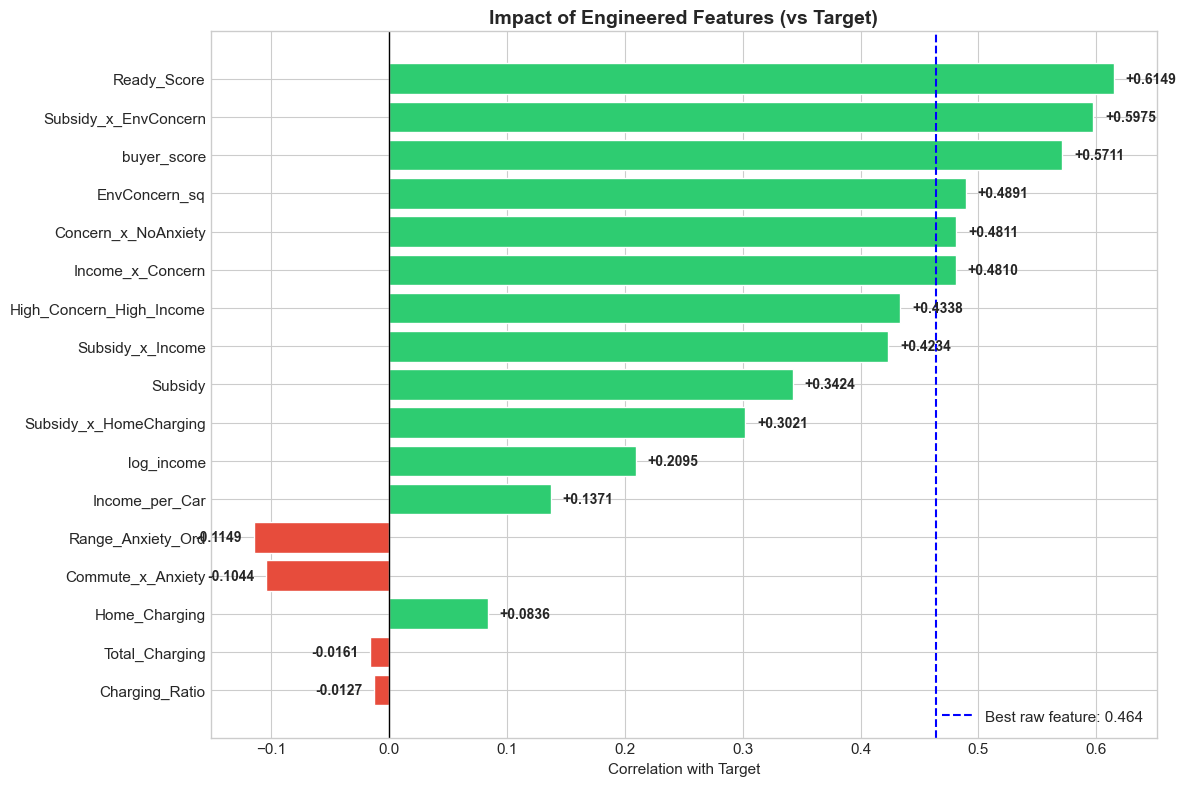


*** FEATURES THAT BEAT THE BEST RAW FEATURE (0.464): ***
  Income_x_Concern                    corr = +0.4810  <-- WINNER!
  Concern_x_NoAnxiety                 corr = +0.4811  <-- WINNER!
  EnvConcern_sq                       corr = +0.4891  <-- WINNER!
  buyer_score                         corr = +0.5711  <-- WINNER!
  Subsidy_x_EnvConcern                corr = +0.5975  <-- WINNER!
  Ready_Score                         corr = +0.6149  <-- WINNER!


In [45]:
# === MEASURE THE IMPACT OF EACH NEW FEATURE ===
# Correlation with target tells us how linearly predictive each feature is

new_cols = [c for c in train_fe.columns if c not in train.columns] + ['buyer_score']

results = []
for col in new_cols:
    corr = train_fe[col].corr(train_fe['target'])
    results.append({'Feature': col, 'Correlation': corr, 'Abs_Corr': abs(corr)})

results_df = pd.DataFrame(results).sort_values('Abs_Corr', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in results_df['Correlation']]
bars = ax.barh(results_df['Feature'], results_df['Correlation'], color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('Correlation with Target')
ax.set_title('Impact of Engineered Features (vs Target)', fontweight='bold', fontsize=14)

for bar, val in zip(bars, results_df['Correlation']):
    ax.text(val + (0.01 if val > 0 else -0.01), bar.get_y() + bar.get_height()/2.,
            f'{val:+.4f}', va='center', ha='left' if val > 0 else 'right',
            fontweight='bold', fontsize=10)

# Add a reference line for the best RAW feature
best_raw = 0.464  # Environmental_Concern correlation
ax.axvline(x=best_raw, color='blue', linestyle='--', linewidth=1.5,
           label=f'Best raw feature: {best_raw:.3f}')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

# Highlight the winners
print('\n*** FEATURES THAT BEAT THE BEST RAW FEATURE (0.464): ***')
for _, row in results_df.iterrows():
    if row['Abs_Corr'] > 0.464:
        print(f"  {row['Feature']:35s} corr = {row['Correlation']:+.4f}  <-- WINNER!")

In [46]:
# === SAVE ENGINEERED DATASETS ===
train_fe.to_csv('dataset/train_engineered.csv', index=False)
test_fe.to_csv('dataset/test_engineered.csv', index=False)

print('Engineered datasets saved!')
print(f'  -> dataset/train_engineered.csv ({train_fe.shape})')
print(f'  -> dataset/test_engineered.csv  ({test_fe.shape})')

Engineered datasets saved!
  -> dataset/train_engineered.csv ((668665, 36))
  -> dataset/test_engineered.csv  ((286571, 31))
